{'topic': '莲花', 'poem': '《爱莲说》\n玉立亭亭水中央，不枝不蔓自幽香。\n淤泥不染真君子，翠盖摇风送晚凉。\n月下清姿凝素影，波心淡荡沐霞光。\n濂溪千古爱莲语，一片禅心入渺茫。\n\n赏析：这首作品以莲花为吟咏对象，通过“玉立亭亭”、“淤泥不染”等生动意象，展现了莲的高洁与清雅。诗中“翠盖摇风”、“月下清姿”等句，巧妙勾勒出莲在风月中的绰约风姿。尾联引入周敦颐爱莲典故，并以“禅心入渺茫”收束，赋予莲花超脱尘俗的禅意，意境深远。', 'content_type': 'poem', 'content_Chinese': '一首诗'}
{'topic': '莲花', 'joke': '一个关于莲花的笑话：  \n\n有一天，莲花、荷花和睡莲在池塘边聚会，荷花先开口：“我们三个长得这么像，到底怎么区分啊？”  \n莲花淡定地说：“很简单，我就是‘出淤泥而不染’的代表，高洁！”  \n荷花接着说：“我‘接天莲叶无穷碧’，主打一个壮观。”  \n睡莲懒洋洋地打了个哈欠：“别吵了，我就是你们中间那个‘一直瘫在水面上，懒得站起来的’……”  \n莲花和荷花齐声问：“那我们仨到底谁是真正的‘花中君子’？”  \n睡莲翻了个白眼：“都别争了，咱们只是好看，真正的‘莲花君’只会说——‘来，帮我拍张照，记得加滤镜！’”  \n\n（笑话核心：莲花常被赋予高洁寓意，但睡莲的“躺平”吐槽打破了严肃形象。）', 'content_type': 'joke', 'content_Chinese': '一个笑话'}
{'topic': '莲花', 'content_type': ''}


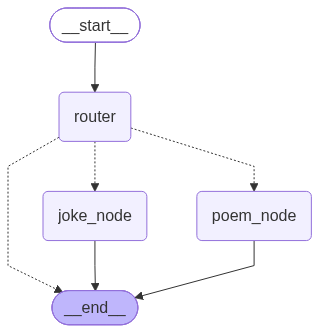

In [5]:

from typing import TypedDict, Literal

from IPython.display import display
from dotenv import load_dotenv
from langchain_deepseek import ChatDeepSeek
from langgraph.constants import END, START
from langgraph.graph import StateGraph
from langgraph.types import Command

load_dotenv(override=True)

# 获取模型
model = ChatDeepSeek(
    model="deepseek-v4-flash",
    extra_body={"thinking": {"type": "disabled"}}
)


# 1、定义状态
# 1.1 全局状态
class OverAllState(TypedDict):
    topic: str
    poem: str
    joke: str
    content_type: Literal["poem", "joke"]
    content_Chinese: str


# 2、定义节点节点
# 工作节点 "__end__"就是节点END
def router(state: OverAllState) -> Command[Literal["poem_node", "joke_node", "__end__"]]:
    if state["content_type"] == "poem":
        return Command(
            update={"content_Chinese": "一首诗"},
            goto="poem_node"
        )
    elif state["content_type"] == "joke":
        return Command(
            update={"content_Chinese": "一个笑话"},
            goto="joke_node"
        )
    else:
        return Command(
            goto=END
        )


def poem_node(state: OverAllState) -> OverAllState:
    poem = model.invoke([f"写一首关于{state['topic']}主题的{state['content_Chinese']}"]).content
    return {
        "poem": poem
    }


def joke_node(state: OverAllState) -> OverAllState:
    joke = model.invoke([f"写一个关于{state['topic']}主题的{state['content_Chinese']}"]).content
    return {
        "joke": joke
    }


# 4、构建图
builder = StateGraph(state_schema=OverAllState)

builder.add_node("router", router)
builder.add_node("poem_node", poem_node)
builder.add_node("joke_node", joke_node)
#添加条件边
builder.add_edge(START, "router")
builder.add_edge("poem_node", END)
builder.add_edge("joke_node", END)

graph = builder.compile()
res = graph.invoke({"topic": "莲花", "content_type": "poem"})
print(res)
print("=" * 50)

graph = builder.compile()
res = graph.invoke({"topic": "莲花", "content_type": "joke"})
print(res)
print("=" * 50)

graph = builder.compile()
res = graph.invoke({"topic": "莲花", "content_type": ""})
print(res)

display(graph)
